In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
data = pd.read_csv(r'C:\Users\USER\Documents\Projects\DCA-ML\data\raw\monthly_production_data.csv')

In [3]:
data.head(5)

,Date,Total_Produced_Days,Monthly_Oil_STB,Monthly_Gas_MSCF,Monthly_Water_STB,Bean_Size_64ths,THP_psi,Cum_Oil_MSTB
0,01/01/2021,30,32891.49,30598.82,2320.56,32,822.2,32.891
1,02/01/2021,26,25584.19,25066.18,2213.95,32,807.5,58.476
2,03/01/2021,31,29809.15,30465.22,3100.03,32,787.0,88.285
3,04/01/2021,28,23535.83,24862.17,2839.44,32,757.6,111.821
4,05/01/2021,29,23709.75,25785.93,3261.90,32,756.2,135.530


In [11]:
data.describe()

,Total_Produced_Days,Monthly_Oil_STB,Monthly_Gas_MSCF,Monthly_Water_STB,Bean_Size_64ths,THP_psi,Cum_Oil_MSTB
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,28.800000,10281.705500,13652.482333,3221.240667,31.733333,441.121667,417.652400
std,3.292518,7004.360204,6372.741576,591.963853,2.065591,184.110265,158.929334
min,8.000000,2701.170000,3868.840000,1065.690000,16.000000,200.700000,32.891000
25%,28.000000,5186.482500,8788.232500,2809.382500,32.000000,278.300000,318.708750
50%,30.000000,7765.185000,11656.270000,3271.900000,32.000000,407.550000,455.300000
75%,31.000000,12559.697500,16321.050000,3646.607500,32.000000,586.175000,548.700000
max,31.000000,32891.490000,30598.820000,4187.990000,32.000000,822.200000,616.902000


In [4]:
data.columns.tolist()

['Date',
 'Total_Produced_Days',
 'Monthly_Oil_STB',
 'Monthly_Gas_MSCF',
 'Monthly_Water_STB',
 'Bean_Size_64ths',
 'THP_psi',
 'Cum_Oil_MSTB']

In [ ]:
"""To plot a 2 X 1 production performance plot, the row 1 plot will have axis oil rate, GOR, cum oil and water-cut on its four y-axis and the x-axis will be Date. The row 2 will plot Bean Size and THP on its y-axis while the x-axis remains Date also.and
time in months."""

data['Oil Rate (bbl/d)'] = data["Monthly Oil Production (bbl)"] / data["Total_Produced Days"]


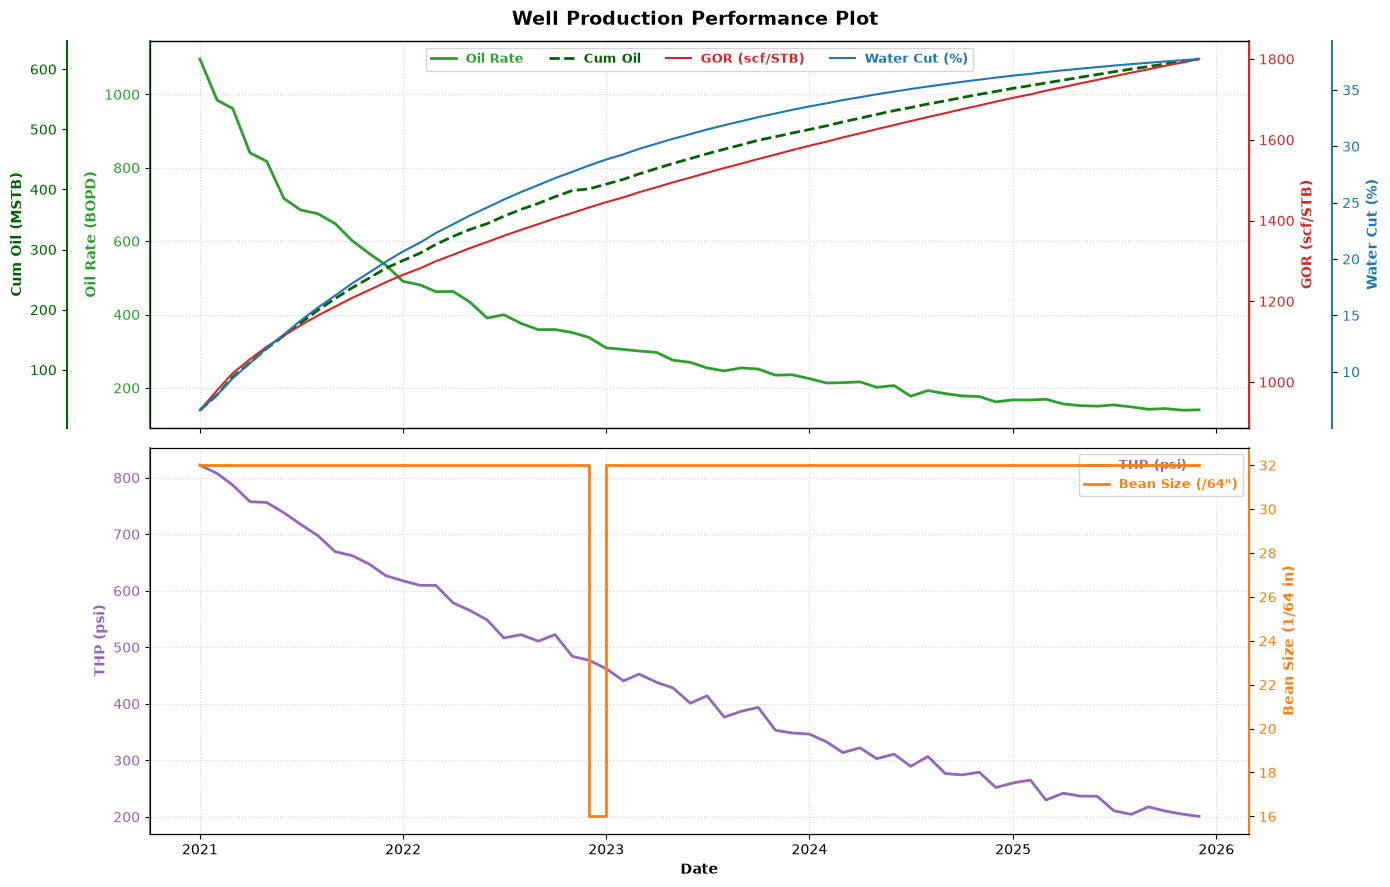

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load & copy production dataset
df = data.copy()

# Ensure Date format & sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date').reset_index(drop=True)

# 2. Calculate daily rates & ratios
safe_days = df['Total_Produced_Days'].replace(0, np.nan)

df['Oil_Rate_BOPD'] = (df['Monthly_Oil_STB'] / safe_days).fillna(0)
df['Gas_Rate_MSCFD'] = (df['Monthly_Gas_MSCF'] / safe_days).fillna(0)
df['Water_Rate_BWPD'] = (df['Monthly_Water_STB'] / safe_days).fillna(0)

# GOR (scf/STB)
df['GOR_scf_stb'] = np.where(
    df['Oil_Rate_BOPD'] > 0,
    (df['Gas_Rate_MSCFD'] * 1000) / df['Oil_Rate_BOPD'],
    0,
)

# Water Cut (%)
total_liquid = df['Oil_Rate_BOPD'] + df['Water_Rate_BWPD']
df['Water_Cut_Pct'] = np.where(
    total_liquid > 0, (df['Water_Rate_BWPD'] / total_liquid) * 100, 0
)

# 3. Define Plot Colors
c_oil = "tab:green"
c_cum = "darkgreen"
c_gor = "tab:red"
c_wcut = "tab:blue"
c_thp = "tab:purple"
c_bean = "tab:orange"

# 4. Create 2 x 1 Figure Layout
fig, (ax1, ax_row2_left) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle(
    "Well Production Performance Plot", fontsize=14, fontweight="bold"
)

# Adjust margins on the right to fit the offset 3rd & 4th y-axes
fig.subplots_adjust(right=0.75)


# ==========================================
# --- ROW 1: 4 DEDICATED Y-AXES ---
# ==========================================

# Axis 1: Oil Rate (Far Left - Default)
(line1,) = ax1.plot(
    df['Date'], df['Oil_Rate_BOPD'], color=c_oil, linewidth=2, label="Oil Rate"
)
ax1.set_ylabel("Oil Rate (BOPD)", color=c_oil, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=c_oil)
ax1.spines["left"].set_color(c_oil)
ax1.spines["left"].set_linewidth(1.5)

# Axis 2: Cum Oil (Offset Left by 60 points)
ax1_cum = ax1.twinx()
ax1_cum.yaxis.set_label_position("left")
ax1_cum.yaxis.set_ticks_position("left")
ax1_cum.spines["left"].set_position(("outward", 60))

(line2,) = ax1_cum.plot(
    df['Date'],
    df['Cum_Oil_MSTB'],
    color=c_cum,
    linewidth=2,
    linestyle="--",
    label="Cum Oil",
)
ax1_cum.set_ylabel("Cum Oil (MSTB)", color=c_cum, fontweight="bold")
ax1_cum.tick_params(axis="y", labelcolor=c_cum)
ax1_cum.spines["left"].set_color(c_cum)
ax1_cum.spines["left"].set_linewidth(1.5)

# Axis 3: GOR (Right 1 - Default Right)
ax1_gor = ax1.twinx()
(line3,) = ax1_gor.plot(
    df['Date'],
    df['GOR_scf_stb'],
    color=c_gor,
    linewidth=1.5,
    label="GOR (scf/STB)",
)
ax1_gor.set_ylabel("GOR (scf/STB)", color=c_gor, fontweight="bold")
ax1_gor.tick_params(axis="y", labelcolor=c_gor)
ax1_gor.spines["right"].set_color(c_gor)
ax1_gor.spines["right"].set_linewidth(1.5)

# Axis 4: Water Cut % (Right 2 - Offset Right by 60 points)
ax1_wcut = ax1.twinx()
ax1_wcut.spines["right"].set_position(("outward", 60))
(line4,) = ax1_wcut.plot(
    df['Date'],
    df['Water_Cut_Pct'],
    color=c_wcut,
    linewidth=1.5,
    label="Water Cut (%)",
)
ax1_wcut.set_ylabel("Water Cut (%)", color=c_wcut, fontweight="bold")
ax1_wcut.tick_params(axis="y", labelcolor=c_wcut)
ax1_wcut.spines["right"].set_color(c_wcut)
ax1_wcut.spines["right"].set_linewidth(1.5)

# Row 1 Grid & Legend
ax1.grid(True, linestyle=":", alpha=0.5)
lines_row1 = [line1, line2, line3, line4]
labels_row1 = [l.get_label() for l in lines_row1]
legend1 = ax1.legend(
    lines_row1, labels_row1, loc="upper center", ncol=4, fontsize=9
)

# Set legend text colors to match the plot lines
for text, line in zip(legend1.get_texts(), lines_row1):
    text.set_color(line.get_color())
    text.set_fontweight("bold")


# ==========================================
# --- ROW 2: OPERATING PARAMETERS ---
# ==========================================

# Row 2 Left Axis: THP
(line5,) = ax_row2_left.plot(
    df['Date'], df['THP_psi'], color=c_thp, linewidth=2, label="THP (psi)"
)
ax_row2_left.set_ylabel("THP (psi)", color=c_thp, fontweight="bold")
ax_row2_left.tick_params(axis="y", labelcolor=c_thp)
ax_row2_left.spines["left"].set_color(c_thp)
ax_row2_left.spines["left"].set_linewidth(1.5)

# Row 2 Right Axis: Bean Size (Stepped)
ax_row2_right = ax_row2_left.twinx()
(line6,) = ax_row2_right.plot(
    df['Date'],
    df['Bean_Size_64ths'],
    color=c_bean,
    linewidth=2,
    drawstyle="steps-post",
    label='Bean Size (/64")',
)
ax_row2_right.set_ylabel(
    "Bean Size (1/64 in)", color=c_bean, fontweight="bold"
)
ax_row2_right.tick_params(axis="y", labelcolor=c_bean)
ax_row2_right.spines["right"].set_color(c_bean)
ax_row2_right.spines["right"].set_linewidth(1.5)

# Row 2 Titles & Legend
ax_row2_left.set_xlabel("Date", fontweight="bold")
ax_row2_left.grid(True, linestyle=":", alpha=0.5)

lines_row2 = [line5, line6]
labels_row2 = [l.get_label() for l in lines_row2]
legend2 = ax_row2_left.legend(
    lines_row2, labels_row2, loc="upper right", fontsize=9
)

# Set Row 2 legend text colors to match plot lines
for text, line in zip(legend2.get_texts(), lines_row2):
    text.set_color(line.get_color())
    text.set_fontweight("bold")

# Display
plt.tight_layout()
plt.show()

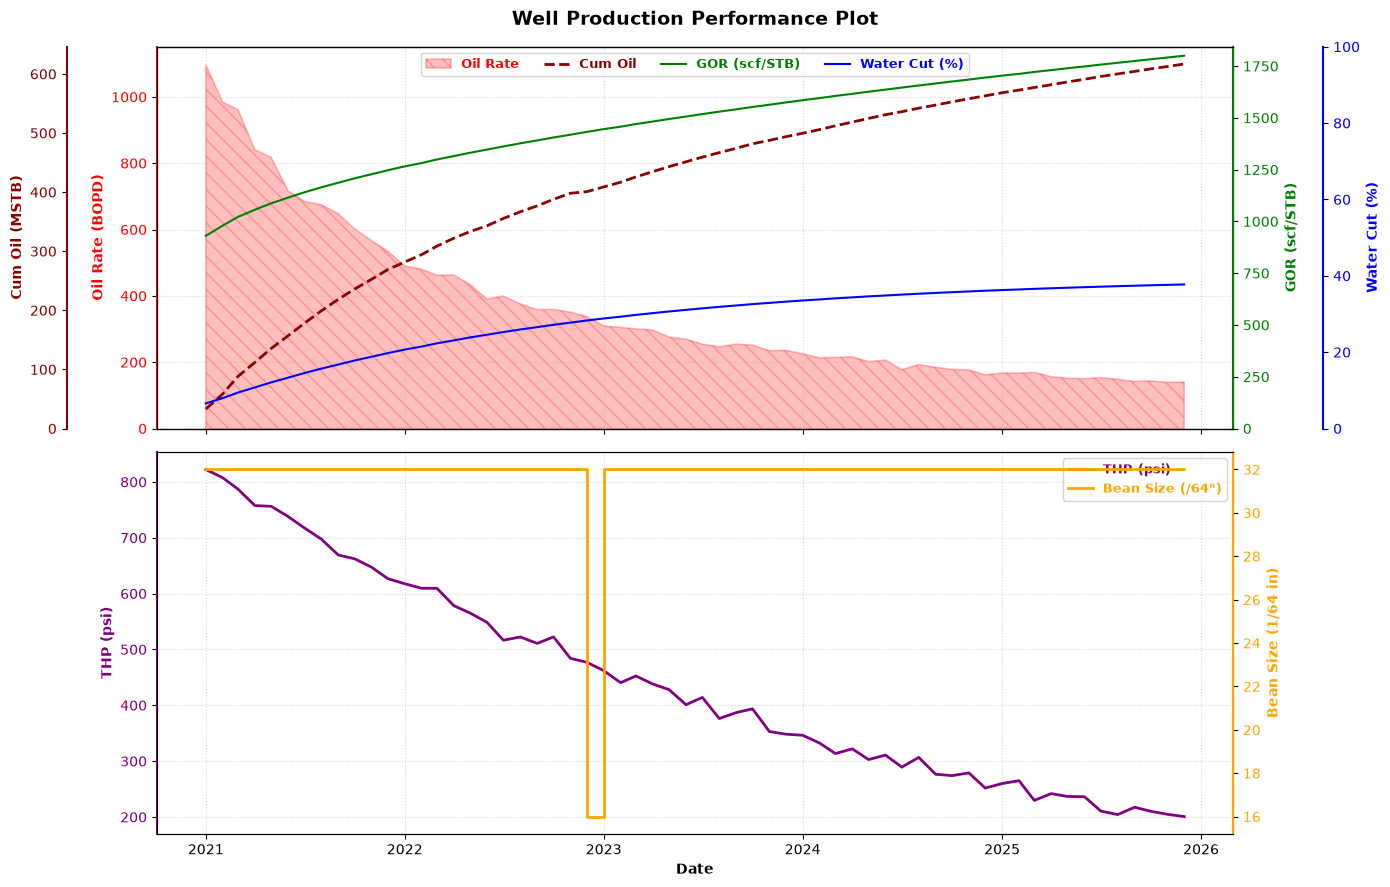

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load & copy production dataset
df = data.copy()

# Ensure Date format & sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date').reset_index(drop=True)

# 2. Calculate daily rates & ratios
safe_days = df['Total_Produced_Days'].replace(0, np.nan)

df['Oil_Rate_BOPD'] = (df['Monthly_Oil_STB'] / safe_days).fillna(0)
df['Gas_Rate_MSCFD'] = (df['Monthly_Gas_MSCF'] / safe_days).fillna(0)
df['Water_Rate_BWPD'] = (df['Monthly_Water_STB'] / safe_days).fillna(0)

# GOR (scf/STB)
df['GOR_scf_stb'] = np.where(
    df['Oil_Rate_BOPD'] > 0,
    (df['Gas_Rate_MSCFD'] * 1000) / df['Oil_Rate_BOPD'],
    0,
)

# Water Cut (%)
total_liquid = df['Oil_Rate_BOPD'] + df['Water_Rate_BWPD']
df['Water_Cut_Pct'] = np.where(
    total_liquid > 0, (df['Water_Rate_BWPD'] / total_liquid) * 100, 0
)

# 3. Define Requested Color Palette
c_oil = "red"
c_cum = "darkred"
c_gor = "green"
c_wcut = "blue"
c_thp = "purple"
c_bean = "orange"

# 4. Create 2 x 1 Figure Layout
fig, (ax1, ax_row2_left) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle(
    "Well Production Performance Plot", fontsize=14, fontweight="bold"
)

# Adjust margins on right & left to fit 4 distinct y-axes
fig.subplots_adjust(left=0.12, right=0.88)


# ==========================================
# --- ROW 1: 4 DEDICATED Y-AXES ---
# ==========================================

# Axis 1: Oil Rate (Far Left) - Area Fill with Backward Slashes '\\'
poly_oil = ax1.fill_between(
    df['Date'],
    df['Oil_Rate_BOPD'],
    color=c_oil,
    alpha=0.25,
    hatch="\\\\",
    edgecolor=c_oil,
    linewidth=1.2,
    label="Oil Rate",
)
ax1.set_ylabel("Oil Rate (BOPD)", color=c_oil, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=c_oil)
ax1.spines["left"].set_color(c_oil)
ax1.spines["left"].set_linewidth(1.5)
ax1.set_ylim(bottom=0)

# Axis 2: Cum Oil (Offset Left by 65 points)
ax1_cum = ax1.twinx()
ax1_cum.yaxis.set_label_position("left")
ax1_cum.yaxis.set_ticks_position("left")
ax1_cum.spines["left"].set_position(("outward", 65))

(line_cum,) = ax1_cum.plot(
    df['Date'],
    df['Cum_Oil_MSTB'],
    color=c_cum,
    linewidth=2,
    linestyle="--",
    label="Cum Oil",
)
ax1_cum.set_ylabel("Cum Oil (MSTB)", color=c_cum, fontweight="bold")
ax1_cum.tick_params(axis="y", labelcolor=c_cum)
ax1_cum.spines["left"].set_color(c_cum)
ax1_cum.spines["left"].set_linewidth(1.5)
ax1_cum.set_ylim(bottom=0)

# Axis 3: GOR (Far Right)
ax1_gor = ax1.twinx()
(line_gor,) = ax1_gor.plot(
    df['Date'],
    df['GOR_scf_stb'],
    color=c_gor,
    linewidth=1.5,
    label="GOR (scf/STB)",
)
ax1_gor.set_ylabel("GOR (scf/STB)", color=c_gor, fontweight="bold")
ax1_gor.tick_params(axis="y", labelcolor=c_gor)
ax1_gor.spines["right"].set_color(c_gor)
ax1_gor.spines["right"].set_linewidth(1.5)
ax1_gor.set_ylim(bottom=0)

# Axis 4: Water Cut % (Offset Right by 65 points)
ax1_wcut = ax1.twinx()
ax1_wcut.spines["right"].set_position(("outward", 65))
(line_wcut,) = ax1_wcut.plot(
    df['Date'],
    df['Water_Cut_Pct'],
    color=c_wcut,
    linewidth=1.5,
    label="Water Cut (%)",
)
ax1_wcut.set_ylabel("Water Cut (%)", color=c_wcut, fontweight="bold")
ax1_wcut.tick_params(axis="y", labelcolor=c_wcut)
ax1_wcut.spines["right"].set_color(c_wcut)
ax1_wcut.spines["right"].set_linewidth(1.5)
ax1_wcut.set_ylim(0, 100)

# Row 1 Grid & Legend
ax1.grid(True, linestyle=":", alpha=0.5)

# Build custom handles so legend labels match colors precisely
handles_row1 = [poly_oil, line_cum, line_gor, line_wcut]
labels_row1 = [h.get_label() for h in handles_row1]
legend1 = ax1.legend(
    handles_row1, labels_row1, loc="upper center", ncol=4, fontsize=9
)

# Match Legend Text Color to Curve Color
colors_row1 = [c_oil, c_cum, c_gor, c_wcut]
for text, color in zip(legend1.get_texts(), colors_row1):
    text.set_color(color)
    text.set_fontweight("bold")


# ==========================================
# --- ROW 2: OPERATING PARAMETERS ---
# ==========================================

# Row 2 Left Axis: THP
(line_thp,) = ax_row2_left.plot(
    df['Date'], df['THP_psi'], color=c_thp, linewidth=2, label="THP (psi)"
)
ax_row2_left.set_ylabel("THP (psi)", color=c_thp, fontweight="bold")
ax_row2_left.tick_params(axis="y", labelcolor=c_thp)
ax_row2_left.spines["left"].set_color(c_thp)
ax_row2_left.spines["left"].set_linewidth(1.5)

# Row 2 Right Axis: Bean Size (Stepped Plot)
ax_row2_right = ax_row2_left.twinx()
(line_bean,) = ax_row2_right.plot(
    df['Date'],
    df['Bean_Size_64ths'],
    color=c_bean,
    linewidth=2,
    drawstyle="steps-post",
    label='Bean Size (/64")',
)
ax_row2_right.set_ylabel("Bean Size (1/64 in)", color=c_bean, fontweight="bold")
ax_row2_right.tick_params(axis="y", labelcolor=c_bean)
ax_row2_right.spines["right"].set_color(c_bean)
ax_row2_right.spines["right"].set_linewidth(1.5)

# Row 2 Grid & Legend
ax_row2_left.set_xlabel("Date", fontweight="bold")
ax_row2_left.grid(True, linestyle=":", alpha=0.5)

handles_row2 = [line_thp, line_bean]
labels_row2 = [h.get_label() for h in handles_row2]
legend2 = ax_row2_left.legend(
    handles_row2, labels_row2, loc="upper right", fontsize=9
)

colors_row2 = [c_thp, c_bean]
for text, color in zip(legend2.get_texts(), colors_row2):
    text.set_color(color)
    text.set_fontweight("bold")

# Render
plt.tight_layout()
plt.show()

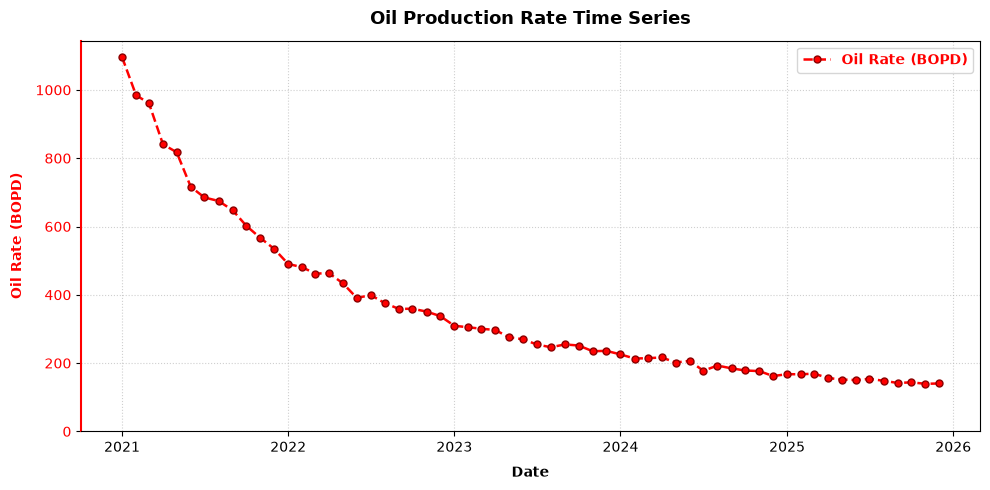

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load & prep data
df = data.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date').reset_index(drop=True)

# Calculate daily Oil Rate
safe_days = df['Total_Produced_Days'].replace(0, np.nan)
df['Oil_Rate_BOPD'] = (df['Monthly_Oil_STB'] / safe_days).fillna(0)

# 2. Plot Setup
fig, ax = plt.subplots(figsize=(10, 5))

# Line plot with markers ('o--' creates a dashed line with circular dots)
ax.plot(
    df['Date'],
    df['Oil_Rate_BOPD'],
    color="red",
    linestyle="--",
    marker="o",
    markersize=5,
    markerfacecolor="red",
    markeredgecolor="darkred",
    linewidth=1.8,
    label="Oil Rate (BOPD)",
)

# Formatting
ax.set_title(
    "Oil Production Rate Time Series", fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Date", fontweight="bold", labelpad=8)
ax.set_ylabel("Oil Rate (BOPD)", color="red", fontweight="bold", labelpad=8)

ax.tick_params(axis="y", labelcolor="red")
ax.spines["left"].set_color("red")
ax.spines["left"].set_linewidth(1.5)

ax.set_ylim(bottom=0)
ax.grid(True, linestyle=":", alpha=0.6)

# Legend with colored text
legend = ax.legend(loc="upper right", fontsize=10)
for text in legend.get_texts():
    text.set_color("red")
    text.set_fontweight("bold")

plt.tight_layout()
plt.show()